### 🐳 決定木(Decision Tree)によるクラスター判定式の作成

#### 📊数量化Ⅰ類をやってみる


=== tsne_x: 実測値 vs 予測値（サンプル） ===
     tsne_x  tsne_x_pred
0  0.879230     0.834194
1  0.879230     0.834194
2  0.521429     0.912852
3  0.521429     0.912852
4  0.788567     1.094748

=== tsne_y: 実測値 vs 予測値（サンプル） ===
     tsne_y  tsne_y_pred
0  0.211924     0.190396
1  0.211924     0.190396
2  0.839543     0.669563
3  0.839543     0.669563
4  0.300815     0.579952

=== 相関係数（ピアソン） ===
tsne_x vs tsne_x_pred : 0.9002
tsne_y vs tsne_y_pred : 0.9177


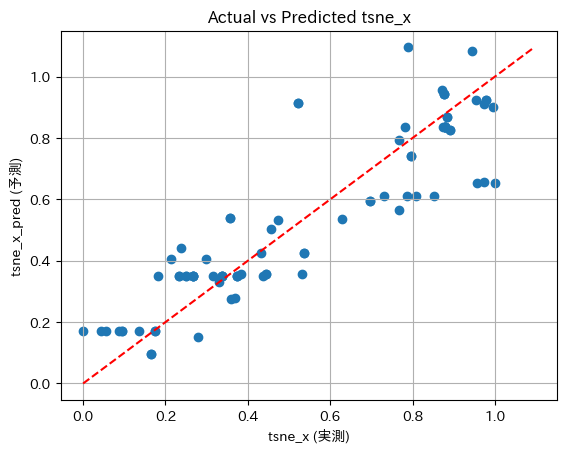

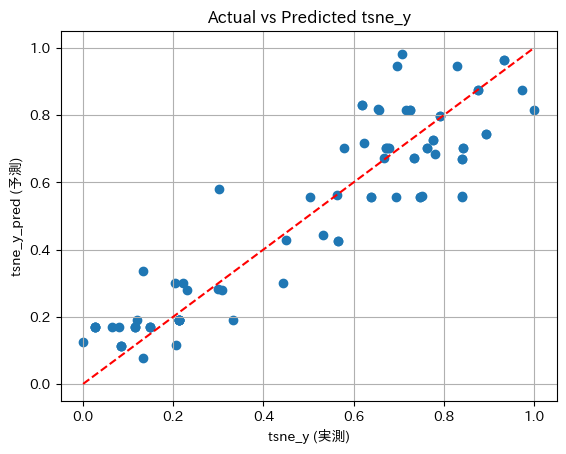

In [7]:
# =============================================
# 数量化Ⅰ類（tsne_x / tsne_y）分析用 Python コード
# =============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt   # ← 追加
import japanize_matplotlib

# ================================
# 1. データ読み込み
# ================================
df = pd.read_csv("../data/csv/20251104_NonWire_3-5.csv")

# 目的変数（2種類）
y_x = df["tsne_x"].values
y_y = df["tsne_y"].values

# 説明変数
categorical_cols = ["シーズン", "タイプ", "シーン1", "シーン2", "シルエット"]
ordinal_col = ["補整力"]  # 順序尺度

# --------------------------------------
# 2. OneHotEncoder 学習（既存データで fit する）
# --------------------------------------
enc = OneHotEncoder(sparse_output=False, drop=None)
X_cat = enc.fit_transform(df[categorical_cols])
cat_feature_names = enc.get_feature_names_out(categorical_cols)

# 補整力（順序尺度）を追加
X_ord = df[ordinal_col].values
X_all = np.hstack([X_cat, X_ord])

# --------------------------------------
# 3. 線形回帰モデル学習（数量化Ⅰ類）
# --------------------------------------
model_x = LinearRegression()
model_x.fit(X_all, y_x)

model_y = LinearRegression()
model_y.fit(X_all, y_y)

# --------------------------------------
# 4. 新しいデータ new_df を読み込む
# --------------------------------------
new_df = pd.read_csv("../data/csv/20251104_NonWire_3-5.csv")

# --------------------------------------
# 5. 新しいデータを同じ前処理で変換
# --------------------------------------
X_new_cat = enc.transform(new_df[categorical_cols])
X_new_ord = new_df[ordinal_col].values
X_new_all = np.hstack([X_new_cat, X_new_ord])

# --------------------------------------
# 6. 新しいデータの tsne_x / tsne_y を推定（predict）
# --------------------------------------
new_df["tsne_x_pred"] = model_x.predict(X_new_all)
new_df["tsne_y_pred"] = model_y.predict(X_new_all)

# --------------------------------------
# 7. 元の値と予測値の比較（サンプル表示）
# --------------------------------------
print("\n=== tsne_x: 実測値 vs 予測値（サンプル） ===")
print(new_df[["tsne_x", "tsne_x_pred"]].head())

print("\n=== tsne_y: 実測値 vs 予測値（サンプル） ===")
print(new_df[["tsne_y", "tsne_y_pred"]].head())

# --------------------------------------
# 8. 相関係数（ピアソン）を計算
# --------------------------------------
corr_x = new_df["tsne_x"].corr(new_df["tsne_x_pred"])
corr_y = new_df["tsne_y"].corr(new_df["tsne_y_pred"])

print("\n=== 相関係数（ピアソン） ===")
print(f"tsne_x vs tsne_x_pred : {corr_x:.4f}")
print(f"tsne_y vs tsne_y_pred : {corr_y:.4f}")

# --------------------------------------
# 10. 散布図を描画
# --------------------------------------

# tsne_x 散布図
plt.figure()
plt.scatter(new_df["tsne_x"], new_df["tsne_x_pred"])
plt.xlabel("tsne_x (実測)")
plt.ylabel("tsne_x_pred (予測)")
plt.title("Actual vs Predicted tsne_x")
plt.grid(True)

# 45度線（理想線）：必要なら使う
min_val = min(new_df["tsne_x"].min(), new_df["tsne_x_pred"].min())
max_val = max(new_df["tsne_x"].max(), new_df["tsne_x_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()

# tsne_y 散布図
plt.figure()
plt.scatter(new_df["tsne_y"], new_df["tsne_y_pred"])
plt.xlabel("tsne_y (実測)")
plt.ylabel("tsne_y_pred (予測)")
plt.title("Actual vs Predicted tsne_y")
plt.grid(True)

# 45度線
min_val = min(new_df["tsne_y"].min(), new_df["tsne_y_pred"].min())
max_val = max(new_df["tsne_y"].max(), new_df["tsne_y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--')

plt.show()

# --------------------------------------
# 11. 保存
# --------------------------------------
new_df.to_csv("../data/csv/20251104_NonWire_tsne_predicted.csv",index=False, encoding="utf-8-sig")


=== 決定木モデルの正解率（accuracy） ===
0.7727

=== 特徴量の重要度（上位） ===
        feature  importance
16          補整力    0.269682
9      シーン1_見せる    0.249512
7   タイプ_一般~グラマー    0.165273
13     シルエット_自然    0.119956
12      シーン2_日中    0.092729
15  シルエット_高さ/自然    0.038942
11      シーン2_就寝    0.035947
6        タイプ_一般    0.027959
10     シーン2_all    0.000000
14     シルエット_高さ    0.000000


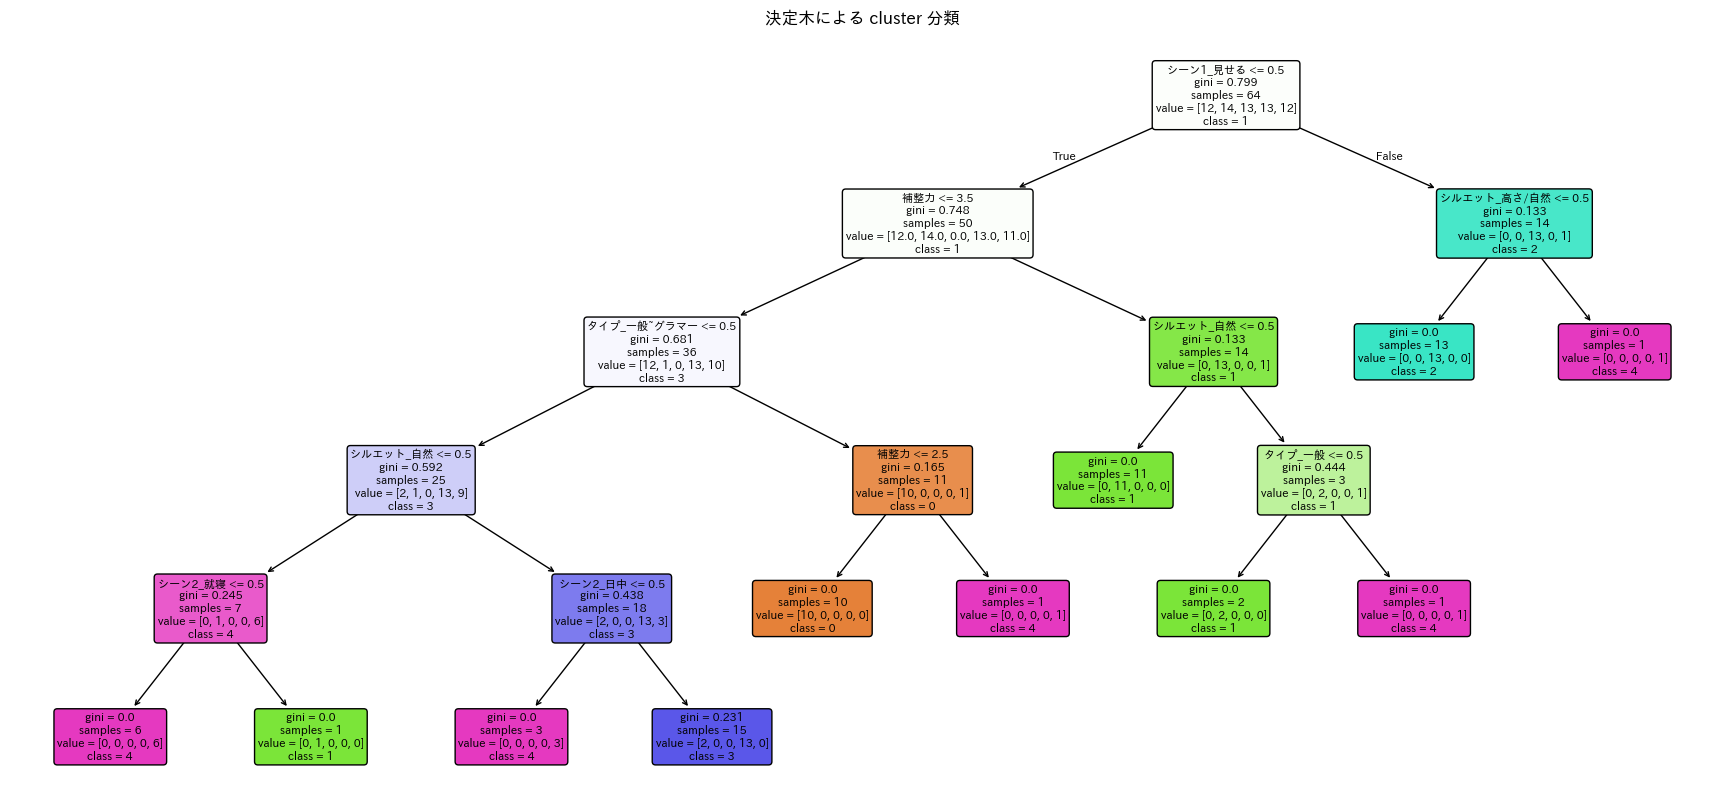

In [8]:
# =============================================
# 決定木による cluster 分類（Python）
# =============================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree
import japanize_matplotlib

# ================================
# 1. データ読み込み
# ================================
df = pd.read_csv("../data/csv/20251104_NonWire_3-5.csv")

# 目的変数（クラスタ番号）
y = df["cluster"].values

# 説明変数
categorical_cols = ["シーズン", "タイプ", "シーン1", "シーン2", "シルエット"]
ordinal_col = ["補整力"]

# カテゴリ変数 OneHotEncoder
enc = OneHotEncoder(sparse_output=False, drop=None)
X_cat = enc.fit_transform(df[categorical_cols])
cat_feature_names = enc.get_feature_names_out(categorical_cols)

# 補整力（順序尺度）を追加
X_ord = df[ordinal_col].values

# 特徴量統合
X = np.hstack([X_cat, X_ord])
feature_names = list(cat_feature_names) + ordinal_col

# ================================
# 2. 学習用 / テスト用に分割
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ================================
# 3. 決定木モデル学習
# ================================
clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,          # 適度に制限しないと過学習する
    random_state=42
)
clf.fit(X_train, y_train)

# ================================
# 4. 精度チェック
# ================================
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n=== 決定木モデルの正解率（accuracy） ===\n{accuracy:.4f}")

# ================================
# 5. 重要度（Feature Importance）
# ================================
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== 特徴量の重要度（上位） ===")
print(fi.head(10))

# ================================
# 6. 決定木の可視化
# ================================
plt.figure(figsize=(22, 10))
tree.plot_tree(
    clf,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(df["cluster"].unique())],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("決定木による cluster 分類")
plt.show()


=== グリッドサーチ結果（決定木） ===
最適パラメータ: {'max_depth': 4, 'min_samples_leaf': 1}

=== 決定木の正解率 ===
0.7273

=== 決定木の分類レポート ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       0.75      0.60      0.67         5
           2       1.00      0.50      0.67         4
           3       0.67      1.00      0.80         4
           4       0.50      0.60      0.55         5

    accuracy                           0.73        22
   macro avg       0.78      0.74      0.74        22
weighted avg       0.77      0.73      0.72        22


=== ランダムフォレストの正解率 ===
0.8182

=== ランダムフォレストの分類レポート ===
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         4
           1       1.00      0.60      0.75         5
           2       1.00      0.50      0.67         4
           3       1.00      1.00      1.00         4
           4       0.62      1.00      0.77         5

    accuracy

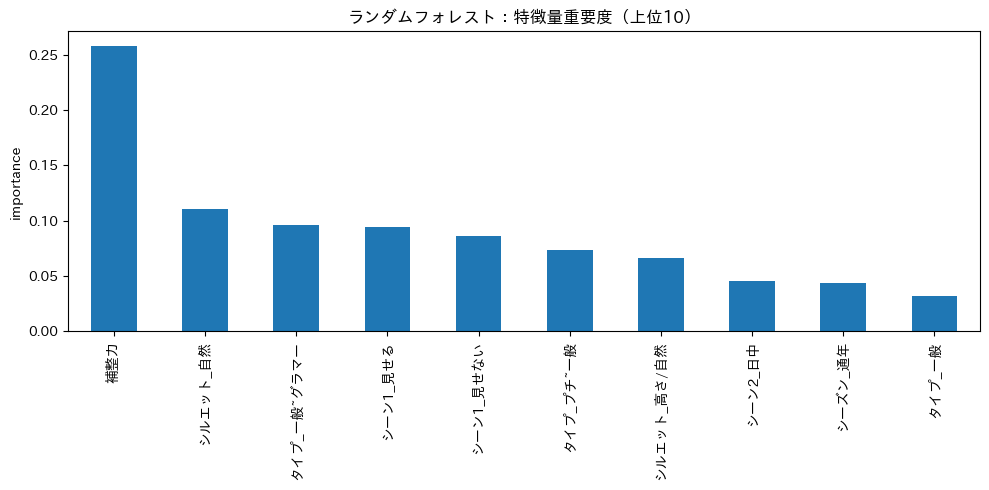


=== SHAP summary plot（class 0 の例） ===


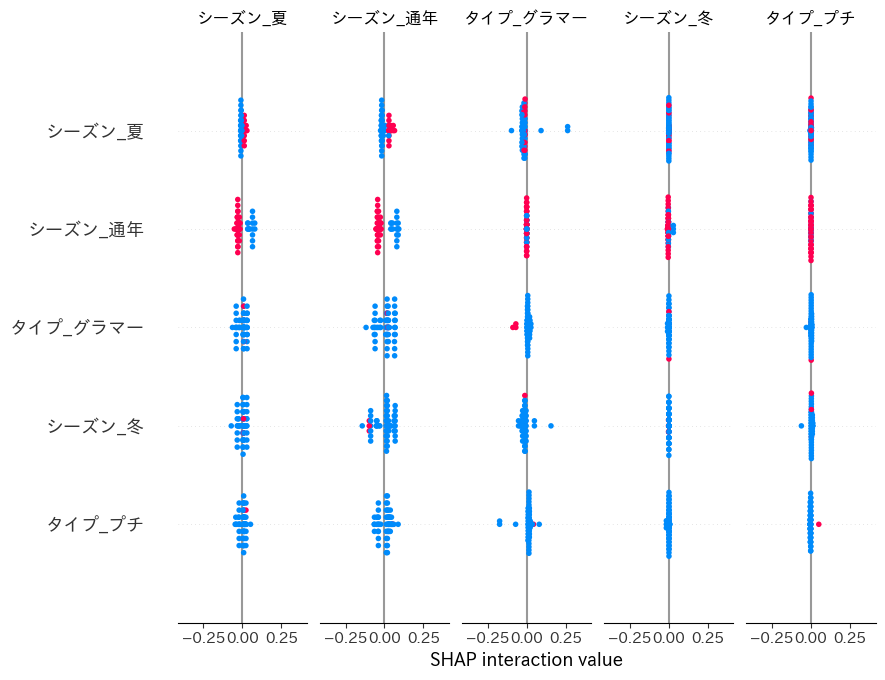


=== 商品ごとの cluster 推定値を保存しました ===
../data/csv/20251104_NonWire_cluster_pred_tree_rf.csv


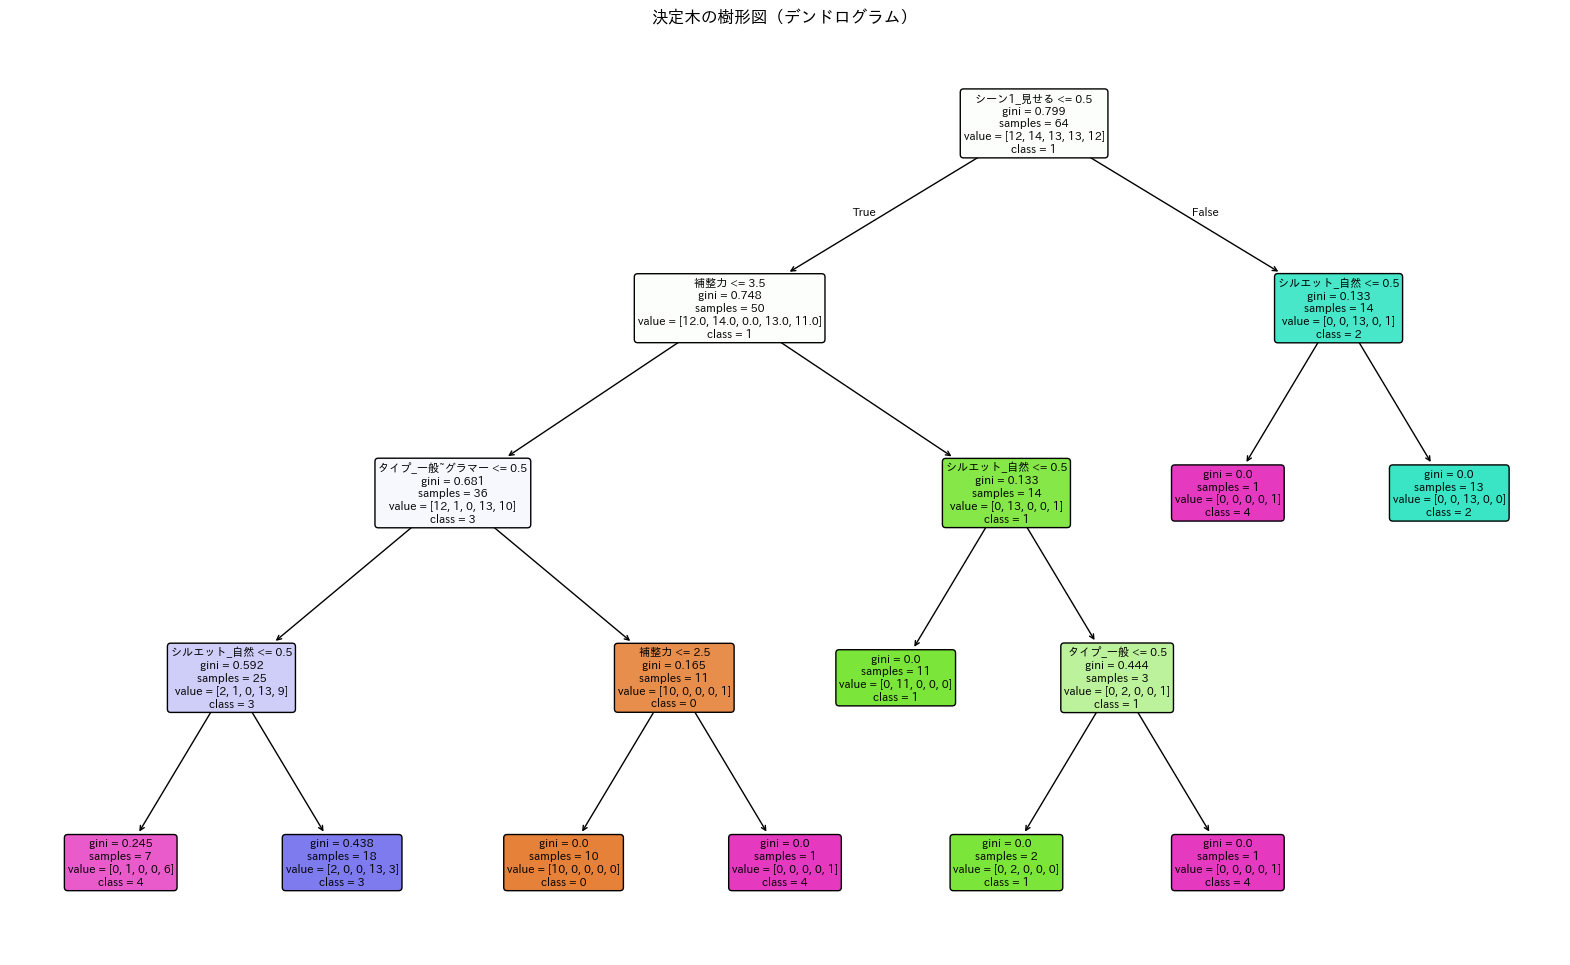

In [12]:
# =============================================
# 決定木 & ランダムフォレスト による cluster 分類
# （数量化Ⅰ類と同じ説明変数を使用）
# =============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import japanize_matplotlib  # 日本語表示用（なければコメントアウト）

# ================================
# 1. データ読み込み
# ================================
df = pd.read_csv("../data/csv/20251104_NonWire_3-5.csv")

# 目的変数（クラスタ番号）
y = df["cluster"].values

# 説明変数
categorical_cols = ["シーズン", "タイプ", "シーン1", "シーン2", "シルエット"]
ordinal_col = ["補整力"]  # 順序尺度

# ================================
# 2. OneHot エンコーディング
# ================================
enc = OneHotEncoder(sparse_output=False, drop=None)
X_cat = enc.fit_transform(df[categorical_cols])
cat_feature_names = enc.get_feature_names_out(categorical_cols)

X_ord = df[ordinal_col].values
X = np.hstack([X_cat, X_ord])
feature_names = list(cat_feature_names) + ordinal_col

# ================================
# 3. 学習用 / テスト用に分割
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ================================
# 4. 決定木の max_depth をグリッドサーチ
# ================================
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 2, 3]
}

base_tree = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(
    base_tree,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train, y_train)

best_tree = grid.best_estimator_
print("\n=== グリッドサーチ結果（決定木） ===")
print("最適パラメータ:", grid.best_params_)

# 決定木の精度
y_pred_tree = best_tree.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"\n=== 決定木の正解率 ===\n{acc_tree:.4f}")
print("\n=== 決定木の分類レポート ===")
print(classification_report(y_test, y_pred_tree))

# ================================
# 5. ランダムフォレストによる分類
# ================================
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print(f"\n=== ランダムフォレストの正解率 ===\n{acc_rf:.4f}")
print("\n=== ランダムフォレストの分類レポート ===")
print(classification_report(y_test, y_pred_rf))

# ================================
# 6. 重要度（feature importance）の比較
# ================================
importances_tree = pd.Series(best_tree.feature_importances_, index=feature_names)
importances_rf = pd.Series(rf.feature_importances_, index=feature_names)

print("\n=== 決定木：特徴量重要度（上位10） ===")
print(importances_tree.sort_values(ascending=False).head(10))

print("\n=== ランダムフォレスト：特徴量重要度（上位10） ===")
print(importances_rf.sort_values(ascending=False).head(10))

# 必要なら棒グラフ表示
plt.figure(figsize=(10, 5))
importances_rf.sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("ランダムフォレスト：特徴量重要度（上位10）")
plt.ylabel("importance")
plt.tight_layout()
plt.show()

# ================================
# 7. SHAP による特徴量寄与の分析（ランダムフォレスト）
# ================================
try:
    import shap

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_train)

    print("\n=== SHAP summary plot（class 0 の例） ===")

    # shap_values が「リスト」の場合（多クラス）
    if isinstance(shap_values, list):
        # 例としてクラス0（cluster=0）のSHAP値を表示
        shap.summary_plot(
            shap_values[0],          # ← ここがポイント
            X_train,
            feature_names=feature_names,
            show=True
        )
    else:
        # 2値分類などで配列一個だけ返ってくる場合
        shap.summary_plot(
            shap_values,
            X_train,
            feature_names=feature_names,
            show=True
        )

except ImportError:
    print("\n[注意] shap がインストールされていないため、SHAP 分析はスキップしました。")
    print("  pip install shap でインストールできます。")

# ================================
# 8. 全商品に対する cluster 推定値を付与して CSV 出力
# ================================
# 決定木・ランダムフォレストの予測を全データに対して計算
df["cluster_pred_tree"] = best_tree.predict(X)
df["cluster_pred_rf"] = rf.predict(X)

# 予測確率（必要なら）
proba_rf = rf.predict_proba(X)
# 最も確からしいクラスタの確率
df["cluster_pred_rf_proba_max"] = proba_rf.max(axis=1)

out_path = "../data/csv/20251104_NonWire_cluster_pred_tree_rf.csv"
df.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"\n=== 商品ごとの cluster 推定値を保存しました ===\n{out_path}")

# ================================
# 9. 決定木（best_tree）の樹形図を描画
# ================================
from sklearn import tree

plt.figure(figsize=(20, 12))
tree.plot_tree(
    best_tree,
    feature_names=feature_names,
    class_names=[str(c) for c in np.unique(y)],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("決定木の樹形図（デンドログラム）")
plt.show()



https://www.youtube.com/watch?v=u0IIqeNZOXY